In [101]:
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from scipy.optimize import minimize
from imblearn.over_sampling import SMOTE

from imblearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [104]:
df = pd.read_csv('diabetes.csv')


In [105]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [106]:
df.shape

(768, 9)

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
print(df.columns)


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [7]:
df.isnull().values.any()


False

In [260]:
df.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
Glucose_BMI                 0
Pregnancy_Age               0
dtype: int64

In [122]:
df["Outcome"].unique()

array([1, 0], dtype=int64)

In [8]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [108]:
correlation_matrix = df.corr()
print(correlation_matrix)


                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.129459       0.141282      -0.081672   
Glucose                      0.129459  1.000000       0.152590       0.057328   
BloodPressure                0.141282  0.152590       1.000000       0.207371   
SkinThickness               -0.081672  0.057328       0.207371       1.000000   
Insulin                     -0.073535  0.331357       0.088933       0.436783   
BMI                          0.017683  0.221071       0.281805       0.392573   
DiabetesPedigreeFunction    -0.033523  0.137337       0.041265       0.183928   
Age                          0.544341  0.263514       0.239528      -0.113970   
Outcome                      0.221898  0.466581       0.065068       0.074752   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.073535  0.017683                 -0.033523   
Glucose                   0.331357  0.221

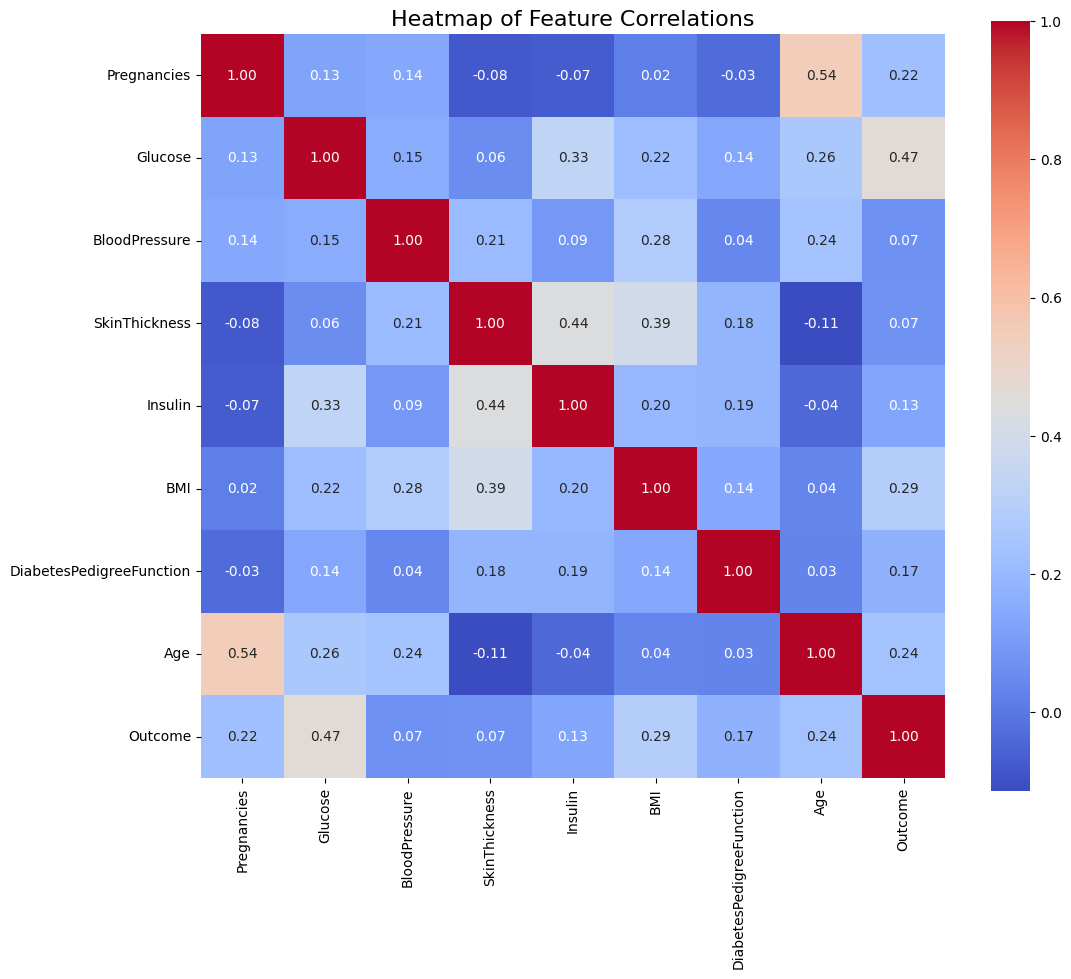

In [100]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Heatmap of Feature Correlations", fontsize=16)
plt.show()

In [66]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

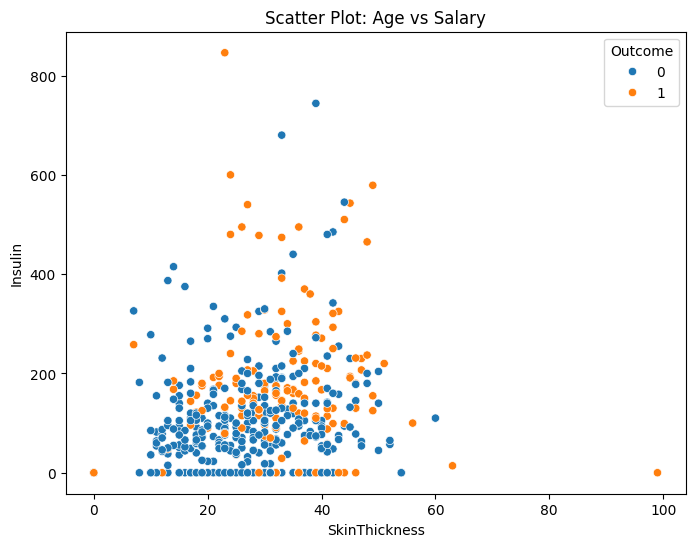

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='SkinThickness', y='Insulin', hue='Outcome')
plt.title('Scatter Plot: Age vs Salary')
plt.show()

In [67]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

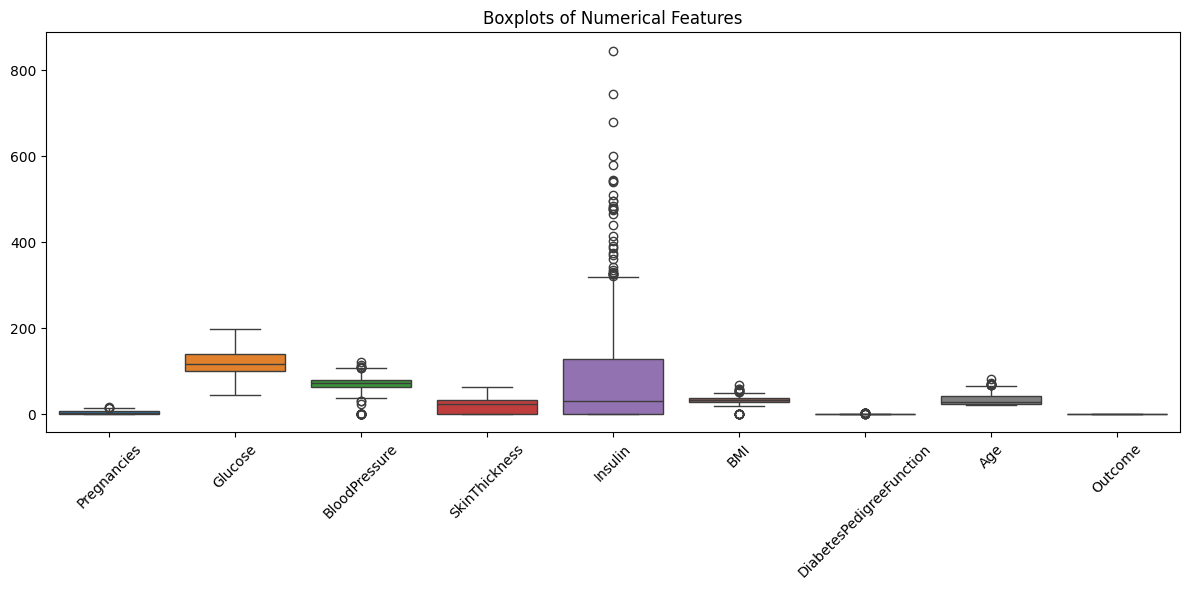

In [23]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=45)
plt.title('Boxplots of Numerical Features')
plt.tight_layout()
plt.show()

In [264]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Glucose_BMI',
       'Pregnancy_Age'],
      dtype='object')

In [109]:


Q1 = df['Glucose'].quantile(0.25)
Q3 = df['Glucose'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

median = df['Glucose'].median()

df['Glucose'] = df['Glucose'].apply(
    lambda x: median if (x < lower_bound or x > upper_bound) else x
)


In [110]:


Q1 = df["SkinThickness"].quantile(0.25)
Q3 = df["SkinThickness"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

median = df["SkinThickness"].median()

df["SkinThickness"] = df["SkinThickness"].apply(
    lambda x: median if (x < lower_bound or x > upper_bound) else x
)


In [ ]:


Q1 = df["Insulin"].quantile(0.25)
Q3 = df["Insulin"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

median = df["Insulin"].median()

df["Insulin"] = df["Insulin"].apply(
    lambda x: Q3 if (x < lower_bound or x > upper_bound) else x
)


In [273]:
df.iloc[:, :-1]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_BMI
0,6,148.0,72,35.0,0,33.6,0.627,50,1,4972.8
1,1,85.0,66,29.0,0,26.6,0.351,31,0,2261.0
2,8,183.0,64,0.0,0,23.3,0.672,32,1,4263.9
3,1,89.0,66,23.0,94,28.1,0.167,21,0,2500.9
4,0,137.0,40,35.0,168,43.1,2.288,33,1,5904.7
...,...,...,...,...,...,...,...,...,...,...
763,10,101.0,76,48.0,180,32.9,0.171,63,0,3322.9
764,2,122.0,70,27.0,0,36.8,0.340,27,0,4489.6
765,5,121.0,72,23.0,112,26.2,0.245,30,0,3170.2
766,1,126.0,60,0.0,0,30.1,0.349,47,1,3792.6


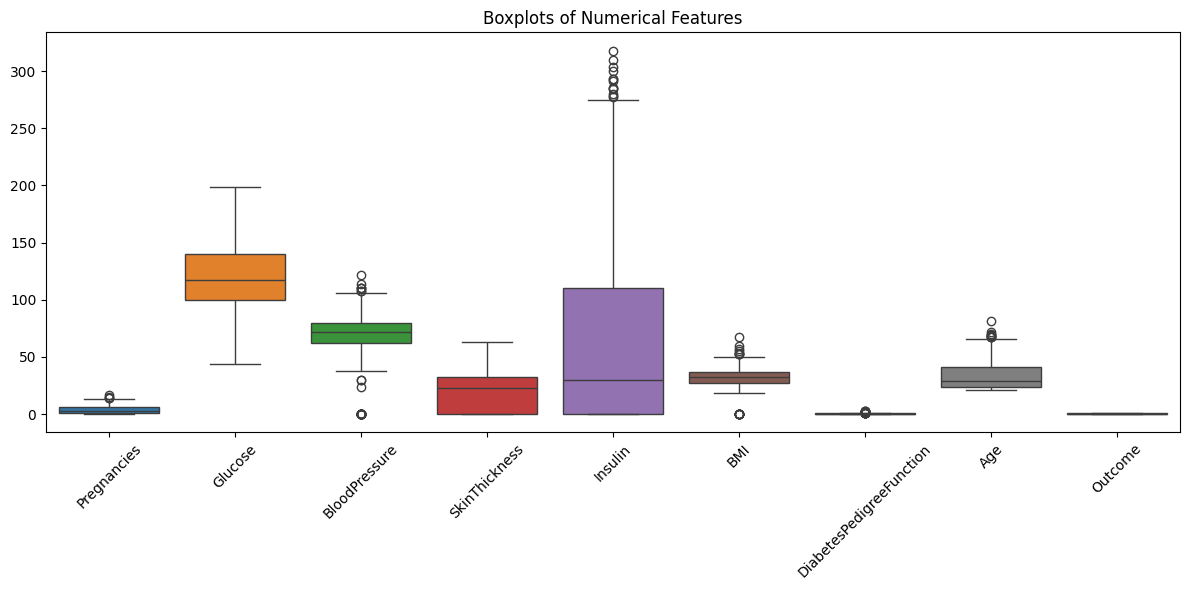

In [112]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=45)
plt.title('Boxplots of Numerical Features')
plt.tight_layout()
plt.show()

In [15]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
X = df.iloc[['Pregnancies', 'Glucose', 'BloodPressure', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]
y = df.iloc[:,-1]

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [92]:
X_train.shape

(614, 6)

In [93]:

k_range = range(1, 21)
cv_scores = []

for k in k_range:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(np.mean(scores))

best_k = k_range[np.argmax(cv_scores)]
print(f"✅ Best k from cross-validation: {best_k}")

final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])

final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 Final Accuracy on Test: {acc:.4f}\n")

print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("🧱 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


✅ Best k from cross-validation: 16

🎯 Final Accuracy on Test: 0.7468

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.74      0.79       100
           1       0.61      0.76      0.68        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.75      0.75       154

🧱 Confusion Matrix:
[[74 26]
 [13 41]]


In [134]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

In [35]:
df.shape

(768, 9)

In [34]:
X_train.shape

(614, 8)

In [ ]:
X_test.shape/

(154, 8)

In [136]:
X.shape

(768, 8)

In [138]:
df.iloc[0,:]

Pregnancies                   6.000
Glucose                     148.000
BloodPressure                72.000
SkinThickness                35.000
Insulin                       0.000
BMI                          33.600
DiabetesPedigreeFunction      0.627
Age                          50.000
Outcome                       1.000
Name: 0, dtype: float64

In [94]:
knn = KNeighborsClassifier(n_neighbors=16,metric='minkowski')
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=16)

In [96]:
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.6818181818181818

In [81]:
knn = KNeighborsClassifier(n_neighbors=18,metric="minkowski" )
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=18)

In [82]:
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7077922077922078

In [83]:
def apply_feature_weights(X, weights):
    return X * weights

def evaluate_knn(weights):
    X_train_weighted = apply_feature_weights(X_train, weights)
    X_test_weighted = apply_feature_weights(X_test, weights)
    
    model = KNeighborsClassifier(n_neighbors=18,metric="minkowski")
    model.fit(X_train_weighted, y_train)
    y_pred = model.predict(X_test_weighted)
    
    return 1 - accuracy_score(y_test, y_pred)  


In [84]:
initial_weights = np.zeros(X.shape[1]) 

result = minimize(evaluate_knn, initial_weights, method='Powell')
optimal_weights = result.x

print("Optimal weights:", optimal_weights)

Optimal weights: [ 1.32893175 -0.60380034  0.8293682   0.03180246  2.21032512  0.43501379
  0.89142096]


In [85]:
X_train_weighted = apply_feature_weights(X_train, optimal_weights)
X_test_weighted = apply_feature_weights(X_test, optimal_weights)

final_model = KNeighborsClassifier(n_neighbors=18,metric="minkowski")
final_model.fit(X_train_weighted, y_train)
final_predictions = final_model.predict(X_test_weighted)

final_accuracy = accuracy_score(y_test, final_predictions)
print("Final Accuracy with optimized weights:", final_accuracy)

Final Accuracy with optimized weights: 0.7922077922077922


In [89]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.74      0.85      0.79       100
           1       0.62      0.44      0.52        54

    accuracy                           0.71       154
   macro avg       0.68      0.65      0.65       154
weighted avg       0.70      0.71      0.69       154

